# 03 - Feature Visualisation

Visualizes the spectral/temporal/connectivity features from `src/features` and confirms the ground-truth workload signature (frontal theta up, posterior alpha down) is recoverable from extracted features, not just visible by eye in raw traces.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data.synthetic import CHANNEL_NAMES, generate_dataset
from src.features.spectral import band_powers
from src.features.connectivity import plv_matrix

epochs = generate_dataset(n_subjects=6, duration_s=180.0, seed=7)

In [2]:
rows = []
for ep in epochs:
    powers = band_powers(ep.data, sfreq=256.0)
    rows.append({
        'workload': ep.workload,
        'frontal_theta': powers['theta_abs'][CHANNEL_NAMES.index('Fz')],
        'posterior_alpha': powers['alpha_abs'][CHANNEL_NAMES.index('Pz')],
    })
df = pd.DataFrame(rows)
df.groupby('workload').mean()

,frontal_theta,posterior_alpha
workload,,
0,57.277561,29.172845
1,85.166370,21.792245
2,136.648383,17.109496


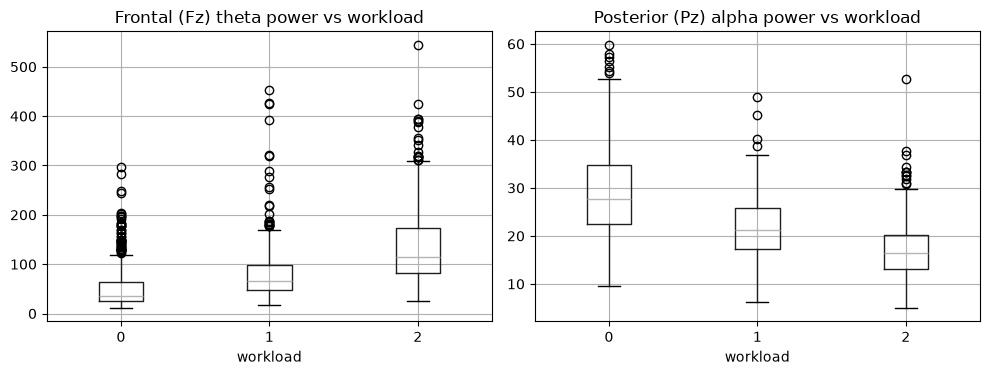

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df.boxplot(column='frontal_theta', by='workload', ax=axes[0])
axes[0].set_title('Frontal (Fz) theta power vs workload')
df.boxplot(column='posterior_alpha', by='workload', ax=axes[1])
axes[1].set_title('Posterior (Pz) alpha power vs workload')
plt.suptitle('')
plt.tight_layout()
plt.show()

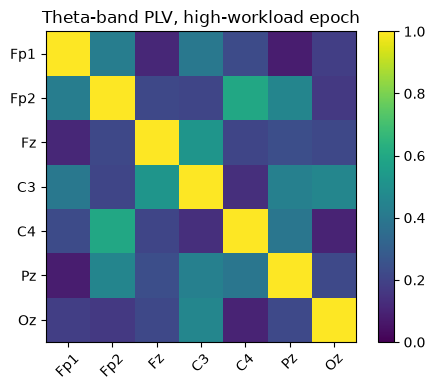

In [4]:
high_workload_epoch = next(ep for ep in epochs if ep.workload == 2)
plv = plv_matrix(high_workload_epoch.data, sfreq=256.0, band=(4.0, 8.0))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(plv, vmin=0, vmax=1, cmap='viridis')
ax.set_xticks(range(len(CHANNEL_NAMES)))
ax.set_xticklabels(CHANNEL_NAMES, rotation=45)
ax.set_yticks(range(len(CHANNEL_NAMES)))
ax.set_yticklabels(CHANNEL_NAMES)
ax.set_title('Theta-band PLV, high-workload epoch')
plt.colorbar(im)
plt.tight_layout()
plt.show()